## CASE IFOOD DS
Objetivo: Direcionar a distribuição de ofertas entre os usuários



##IMPORTANDO BIBLIOTECAS

In [0]:
from pyspark.sql.functions import col
from pyspark.sql.functions import when
from pyspark.sql.functions import col, isnull, isnan, sum as spark_sum
from pyspark.sql.functions import to_date
from pyspark.sql.functions import coalesce
from pyspark.sql import functions as F
from pyspark.sql.functions import count, avg
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql.functions import col, row_number
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pyspark.sql.functions import col, mean as _mean, stddev as _stddev
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from functools import reduce

##TRATANDO BASES

In [0]:
#Chamando bases
df_offers=spark.table('offers')
df_profile=spark.table('profile')
df_transactions=spark.table('transactions')

In [0]:
#Tratando variáveis oferta
df_offers = df_offers \
    .withColumn("web_channel", F.when(F.array_contains("channels", "web"), 1).otherwise(0)) \
    .withColumn("email_channel", F.when(F.array_contains("channels", "email"), 1).otherwise(0)) \
    .withColumn("mobile_channel", F.when(F.array_contains("channels", "mobile"), 1).otherwise(0)) \
    .withColumn("social_channel", F.when(F.array_contains("channels", "social"), 1).otherwise(0))

# Remover a coluna 'channels'
df_offers = df_offers.drop('channels')

In [0]:
#Tratando variáveis
df_transactions = df_transactions.withColumn("amount", col("value.amount")) \
                                 .withColumn("offer_id", col("value.offer_id")) \
                                 .withColumn("offer_id2", col("value.offer_id2")) \
                                 .withColumn("reward", col("value.reward"))\
                                .drop('value')

df_transactions = df_transactions.withColumn("offer_id", coalesce(col("offer_id"), col("offer_id2"))) \
                                 .drop("offer_id2")

df_transactions = df_transactions.withColumn("time_since_test_start", col("time_since_test_start").cast("int"))

In [0]:
#Explorando métricas de transação
df_transactions.summary().display()

summary,account_id,event,time_since_test_start,amount,offer_id,reward
count,306534,306534,306534,138953,167581,33579
mean,2.565638242424101E31,null,15.000926487763184,12.77735615639814,null,4.904136513892611
stddev,0.0,null,8.330109666548198,30.25052863201715,null,2.88664688233728
min,0009655768c64bdeb2e877511632db8f,offer completed,0,0.05,0b1e1539f2cc45b7b9fa7c272da2e1d7,2.0
25%,2.565638242424101E31,null,7,2.78,null,2.0
50%,2.565638242424101E31,null,17,8.89,null,5.0
75%,2.565638242424101E31,null,22,18.07,null,5.0
max,ffff82501cea40309d5fdd7edcca4a07,transaction,29,1062.28,fafdcd668e3743c1bb461111dcafc2a4,10.0


In [0]:
#Explorando métricas de profile
df_profile.summary().display()

summary,age,credit_card_limit,gender,id,registered_on
count,17000,14825,14825,17000,17000
mean,62.53141176470588,65404.9915682968,null,2.565638242424101E31,2.0167034234117646E7
stddev,26.738579945767242,21598.29941022947,null,null,11677.499960793168
min,18,30000.0,F,0009655768c64bdeb2e877511632db8f,20130729
25%,45,49000.0,null,2.565638242424101E31,2.0160526E7
50%,58,64000.0,null,2.565638242424101E31,2.0170802E7
75%,73,80000.0,null,2.565638242424101E31,2.0171229E7
max,118,120000.0,O,ffff82501cea40309d5fdd7edcca4a07,20180726


In [0]:
# Tratar idades inválidas
df_profile = df_profile.withColumn(
    "age",
    when((col("age") < 18) | (col("age") > 100), None).otherwise(col("age")))

# Converter `registered_on` para data
df_profile = df_profile.withColumn("registered_on", to_date(df_profile["registered_on"], "yyyyMMdd"))

In [0]:
# Tirar sem informação
df_profile = df_profile.filter(
    col("gender").isNotNull() & 
    col("age").isNotNull() & 
    col("credit_card_limit").isNotNull()
)

In [0]:
#Distribuição genero
df_profile.groupBy(col('gender')).count().display()

gender,count
M,8484
O,212
F,6124


##UNIFICANDO BASES

In [0]:
# Realizar o primeiro join entre df_profile e df_transactions com base no ID
df_transactions_profile = df_transactions.join(df_profile, df_transactions.account_id == df_profile.id, "inner")\
                          .drop(df_profile.id)

# Realizar o segundo join entre df_ e df_offers com base no offer_id
df_transactions_profile_offers = df_transactions_profile.join(df_offers, df_transactions_profile.offer_id == df_offers.id, "left")\
                    .drop( df_offers.id)

# Filtrar clientes que receberam pelo menos uma oferta
clients_with_offers = df_transactions_profile_offers.filter(F.col("event") == "offer received").select("account_id").distinct()

# Filtrar o DataFrame original para manter apenas clientes com ofertas
df_final= df_transactions_profile_offers.join(clients_with_offers, on="account_id", how="inner")

# Verificar o DataFrame resultante
df_final.select("account_id").distinct().count()


14815

In [0]:
#Formato das variáveis
df_final.printSchema()

root
 |-- account_id: string (nullable = true)
 |-- event: string (nullable = true)
 |-- time_since_test_start: integer (nullable = true)
 |-- amount: double (nullable = true)
 |-- offer_id: string (nullable = true)
 |-- reward: double (nullable = true)
 |-- age: long (nullable = true)
 |-- credit_card_limit: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- registered_on: date (nullable = true)
 |-- discount_value: long (nullable = true)
 |-- duration: double (nullable = true)
 |-- min_value: long (nullable = true)
 |-- offer_type: string (nullable = true)
 |-- web_channel: integer (nullable = true)
 |-- email_channel: integer (nullable = true)
 |-- mobile_channel: integer (nullable = true)
 |-- social_channel: integer (nullable = true)



##TRATANDO VARIÁVEIS

In [0]:
#Tratando formato das variáveis
df_final = df_final.withColumn("age", col("age").cast("int")) \
                   .withColumn("credit_card_limit", col("credit_card_limit").cast("double")) \
                   .withColumn("discount_value", col("discount_value").cast("double")) \
                   .withColumn("duration", col("duration").cast("double")) \
                   .withColumn("min_value", col("min_value").cast("double")) \
                   .withColumn("time_since_test_start", col("time_since_test_start").cast("int"))

In [0]:
# Agregar por cliente para calcular métricas básicas
client_metrics = df_final.groupBy("account_id").agg(
    F.sum(F.when(F.col("event") == "offer received", 1).otherwise(0)).alias("total_offers_received"),
    F.sum(F.when(F.col("event") == "offer viewed", 1).otherwise(0)).alias("total_offers_viewed"),
    F.sum(F.when(F.col("event") == "offer completed", 1).otherwise(0)).alias("total_offers_completed"),
    F.sum(F.when(F.col("event") == "transaction", 1).otherwise(0)).alias("total_transactions"),
    F.avg(F.when(F.col("event") == "transaction", F.col("amount")).otherwise(None)).alias("avg_transaction_amount")
)

In [0]:
offer_details = df_final.groupBy("account_id").agg(
    F.avg("duration").alias("avg_offer_duration"),
    F.avg("discount_value").alias("avg_discount_value"),
    F.avg("min_value").alias("avg_min_value"),
)

In [0]:
# Identificar a última data do registro em "registered_on"
max_date = df_final.select(F.max("registered_on").alias("last_registered_date")).collect()[0]["last_registered_date"]

# Criar DataFrame com agregações adicionais
profile_details = df_final.groupBy("account_id").agg(
    # Pegar o primeiro valor de idade
    F.first("age").alias("age"),
    
    # Pegar o primeiro valor do limite de crédito
    F.first("credit_card_limit").alias("credit_card_limit"),
    
    # Pegar o primeiro valor do gênero
    F.first("gender").alias("gender"),
    
    # Determinar a data mínima de registro por conta
    F.min("registered_on").alias("registered_on")
).withColumn(
  
    # Calcular os dias desde a primeira data de registro até a última data identificada
    "days_since_registration",
    F.datediff(F.lit(max_date), F.to_date("registered_on"))
)

In [0]:
# Calcular taxas de engajamento tratando divisor zero com 0 diretamente
engagement_by_channel = df_final.groupBy("account_id").agg(
    # Taxa de engajamento no canal Mobile
    (F.sum(F.when((F.col("mobile_channel") == 1) & (F.col("event") == "offer viewed"), 1).otherwise(0)) /
     F.when(F.sum(F.when((F.col("mobile_channel") == 1) & (F.col("event") == "offer received"), 1).otherwise(0)) == 0,
            1)  # Definimos 1 simplesmente para evitar o caso de divisão por 0
     .otherwise(F.sum(F.when((F.col("mobile_channel") == 1) & (F.col("event") == "offer received"), 1).otherwise(0)))
     ).alias("engagement_mobile_channel"),

    # Taxa de engajamento no canal Web
    (F.sum(F.when((F.col("web_channel") == 1) & (F.col("event") == "offer viewed"), 1).otherwise(0)) /
     F.when(F.sum(F.when((F.col("web_channel") == 1) & (F.col("event") == "offer received"), 1).otherwise(0)) == 0,
            1)  # Definimos 1 para apenas retornar 0 no numerador
     .otherwise(F.sum(F.when((F.col("web_channel") == 1) & (F.col("event") == "offer received"), 1).otherwise(0)))
     ).alias("engagement_web_channel"),

    # Taxa de engajamento no canal Social
    (F.sum(F.when((F.col("social_channel") == 1) & (F.col("event") == "offer viewed"), 1).otherwise(0)) /
     F.when(F.sum(F.when((F.col("social_channel") == 1) & (F.col("event") == "offer received"), 1).otherwise(0)) == 0,
            1)  # Aqui também tratamos a condição
     .otherwise(F.sum(F.when((F.col("social_channel") == 1) & (F.col("event") == "offer received"), 1).otherwise(0)))
     ).alias("engagement_social_channel")
)

In [0]:
# Calcular o tempo médio entre transações para cada cliente
transactions = df_final.filter(F.col("event") == "transaction").select("account_id", "time_since_test_start")

time_between_transactions = transactions.withColumn(
    "time_diff", 
    F.col("time_since_test_start") - F.lag("time_since_test_start").over(
        Window.partitionBy("account_id").orderBy("time_since_test_start")
    )
).groupBy("account_id").agg(F.avg("time_diff").alias("avg_time_between_transactions"))

In [0]:
# Calcular eventos de conversão por tipo de oferta
conversion_rates = df_final.groupBy("account_id").agg(
    # Para BOGO
    F.sum(F.when((F.col("offer_type") == "bogo") & (F.col("event") == "offer completed"), 1).otherwise(0)).alias("completed_bogo"),
    F.countDistinct(F.when(F.col("offer_type") == "bogo", F.col("offer_id"))).alias("received_bogo"),  # Distintas recebidas

    # Para Discount
    F.sum(F.when((F.col("offer_type") == "discount") & (F.col("event") == "offer completed"), 1).otherwise(0)).alias("completed_discount"),
    F.countDistinct(F.when(F.col("offer_type") == "discount", F.col("offer_id"))).alias("received_discount"),  # Distintas recebidas

    # Para Informational
    F.sum(F.when((F.col("offer_type") == "informational") & (F.col("event") == "offer viewed"), 1).otherwise(0)).alias("viewed_informational"),
    F.countDistinct(F.when(F.col("offer_type") == "informational", F.col("offer_id"))).alias("received_informational")  # Distintas recebidas
)

# Calcular taxas de conversão
conversion_rates = conversion_rates.withColumn(
    "conversion_rate_bogo",
    F.col("completed_bogo") / (F.col("received_bogo") + 1e-6)
).withColumn(
    "conversion_rate_discount",
    F.col("completed_discount") / (F.col("received_discount") + 1e-6)
).withColumn(
    "conversion_rate_informational",
    F.col("viewed_informational") / (F.col("received_informational") + 1e-6)
)


# Criar variável target com base nas taxas de conversão e desempate
conversion_rates = conversion_rates.withColumn(
    "target", 
    F.when(
        (F.col("conversion_rate_bogo") == 0) & 
        (F.col("conversion_rate_discount") == 0) & 
        (F.col("conversion_rate_informational") == 0), 
        "desengajado"
    ).otherwise(
        F.when(
            (F.col("conversion_rate_bogo") > F.col("conversion_rate_discount")) & 
            (F.col("conversion_rate_bogo") > F.col("conversion_rate_informational")), 
            "bogo"
        ).when(
            (F.col("conversion_rate_discount") > F.col("conversion_rate_bogo")) & 
            (F.col("conversion_rate_discount") > F.col("conversion_rate_informational")), 
            "discount"
        ).when(
            (F.col("conversion_rate_informational") > F.col("conversion_rate_bogo")) & 
            (F.col("conversion_rate_informational") > F.col("conversion_rate_discount")), 
            "informational"
        )
    )
)

# Resolver Empates Usando Menor Número de Ofertas Recebidas
# Para bogo vs discount
conversion_rates = conversion_rates.withColumn(
    "target",
    F.when(
        (F.col("conversion_rate_bogo") == F.col("conversion_rate_discount")) &
        (F.col("conversion_rate_bogo") > F.col("conversion_rate_informational")),
        F.when(F.col("received_bogo") < F.col("received_discount"), "bogo").otherwise("discount")
    ).otherwise(F.col("target"))  # Manter o valor anterior do target
)

# Para bogo vs informational
conversion_rates = conversion_rates.withColumn(
    "target",
    F.when(
        (F.col("conversion_rate_bogo") == F.col("conversion_rate_informational")) &
        (F.col("conversion_rate_bogo") > F.col("conversion_rate_discount")),
        F.when(F.col("received_bogo") < F.col("received_informational"), "bogo").otherwise("informational")
    ).otherwise(F.col("target"))  # Manter o valor anterior do target
)

# Para discount vs informational
conversion_rates = conversion_rates.withColumn(
    "target",
    F.when(
        (F.col("conversion_rate_discount") == F.col("conversion_rate_informational")) &
        (F.col("conversion_rate_discount") > F.col("conversion_rate_bogo")),
        F.when(F.col("received_discount") < F.col("received_informational"), "discount").otherwise("informational")
    ).otherwise(F.col("target"))  # Manter o valor anterior do target
)

conversion_rates_final = conversion_rates.filter(F.col("target").isNotNull())


In [0]:
# Lista de DataFrames
dataframes = [
    client_metrics,
    offer_details,
    profile_details,
    engagement_by_channel,
    time_between_transactions,
    conversion_rates_final
]

# Fazer uma sequência de JOINs
df_individuo = reduce(
    lambda df1, df2: df1.join(df2, on="account_id", how="left"),
    dataframes
)

# Ordenar as colunas para ter o "account_id" primeiro
df_individuo = df_individuo.select("account_id", *[col for col in df_individuo.columns if col != "account_id"])

In [0]:
# Para cada coluna, conta os valores nulos
nulos_por_coluna = {c: df_individuo.filter(col(c).isNull()).count() for c in df_individuo.columns}

print(nulos_por_coluna)

{'account_id': 0, 'total_offers_received': 0, 'total_offers_viewed': 0, 'total_offers_completed': 0, 'total_transactions': 0, 'avg_transaction_amount': 333, 'avg_offer_duration': 0, 'avg_discount_value': 0, 'avg_min_value': 0, 'age': 0, 'credit_card_limit': 0, 'gender': 0, 'registered_on': 0, 'days_since_registration': 0, 'engagement_mobile_channel': 0, 'engagement_web_channel': 0, 'engagement_social_channel': 0, 'avg_time_between_transactions': 648, 'completed_bogo': 0, 'received_bogo': 0, 'completed_discount': 0, 'received_discount': 0, 'viewed_informational': 0, 'received_informational': 0, 'conversion_rate_bogo': 0, 'conversion_rate_discount': 0, 'conversion_rate_informational': 0, 'target': 0}


In [0]:
#Tirando nulo
df_individuo = df_individuo.filter(df_individuo.target.isNotNull())

In [0]:
# Categorizar 'age'
# Categorias:
# 0: "18-30"
# 1: "30-45"
# 2: "45-60"
# 3: "Acima de 60"
df_individuo = df_individuo.withColumn(
    "age_category",
    when((df_individuo["age"] >= 18) & (df_individuo["age"] <= 30), 0)
    .when((df_individuo["age"] > 30) & (df_individuo["age"] <= 45), 1)
    .when((df_individuo["age"] > 45) & (df_individuo["age"] <= 60), 2)
    .otherwise(3)
)
# Categorizar 'credit_card_limit'
quartiles = df_individuo.approxQuantile("credit_card_limit", [0.25, 0.5, 0.75], 0.01)
q1, q2, q3 = quartiles[0], quartiles[1], quartiles[2]
# Categorias:
# 0: "Q1 (Baixo)"
# 1: "Q2 (Moderado)"
# 2: "Q3 (Alto)"
# 3: "Q4 (Muito Alto)"
df_individuo = df_individuo.withColumn(
    "credit_card_limit_category",
    when(df_individuo["credit_card_limit"] <= q1, 0)
    .when((df_individuo["credit_card_limit"] > q1) & (df_individuo["credit_card_limit"] <= q2), 1)
    .when((df_individuo["credit_card_limit"] > q2) & (df_individuo["credit_card_limit"] <= q3), 2)
    .otherwise(3)
)
# Categorizar 'total_transactions'
# Baseado em faixas definidas
# Categorias:
# 0: "Baixa (≤5)"
# 1: "Média (6-15)"
# 2: "Alta (>15)"
df_individuo = df_individuo.withColumn(
    "total_transactions_category",
    when(df_individuo["total_transactions"] <= 5, 0)
    .when((df_individuo["total_transactions"] > 5) & (df_individuo["total_transactions"] <= 15), 1)
    .otherwise(2)
)
# Categorizar 'avg_transaction_amount'
quartiles = df_individuo.approxQuantile("avg_transaction_amount", [0.25, 0.5, 0.75], 0.01)
q1, q2, q3 = quartiles[0], quartiles[1], quartiles[2]
# Categorias:
# 0: "Muito Baixo"
# 1: "Baixo"
# 2: "Médio"
# 3: "Alto"
df_individuo = df_individuo.withColumn(
    "avg_transaction_amount_category",
    when(df_individuo["avg_transaction_amount"] <= q1, 0)
    .when((df_individuo["avg_transaction_amount"] > q1) & (df_individuo["avg_transaction_amount"] <= q2), 1)
    .when((df_individuo["avg_transaction_amount"] > q2) & (df_individuo["avg_transaction_amount"] <= q3), 2)
    .otherwise(3)
)
# Categorizar 'days_since_registration'
# Categorias:
# 0: "Novo ≤ 365 dias"
# 1: "Intermediário (366-1000 dias)"
# 2: "Antigo > 1000 dias"
df_individuo = df_individuo.withColumn(
    "days_since_registration_category",
    when(df_individuo["days_since_registration"] <= 365, 0)
    .when((df_individuo["days_since_registration"] > 365) & (df_individuo["days_since_registration"] <= 1000), 1)
    .otherwise(2)
)
# Categorizar 'engagement_mobile_channel'
# Tratando como contínua categorizada de 0 (baixa interação) a 1 (alta interação)
df_individuo = df_individuo.withColumn(
    "engagement_mobile_channel_category",
    when(df_individuo["engagement_mobile_channel"] <= 0.33, 0)  # Baixa
    .when((df_individuo["engagement_mobile_channel"] > 0.33) & (df_individuo["engagement_mobile_channel"] <= 0.66), 1)  # Média
    .otherwise(2)  # Alta
)
# Categorizar 'engagement_web_channel'
# Categorias:
# 0: Baixa (≤0.33)
# 1: Média (0.34-0.66)
# 2: Alta (>0.66)
df_individuo = df_individuo.withColumn(
    "engagement_web_channel_category",
    when(df_individuo["engagement_web_channel"] <= 0.33, 0)
    .when((df_individuo["engagement_web_channel"] > 0.33) & (df_individuo["engagement_web_channel"] <= 0.66), 1)
    .otherwise(2)
)
# Categorizar 'engagement_social_channel'
# Categorias:
# 0: Baixa (≤0.33)
# 1: Média (0.34-0.66)
# 2: Alta (>0.66)
df_individuo = df_individuo.withColumn(
    "engagement_social_channel_category",
    when(df_individuo["engagement_social_channel"] <= 0.33, 0)
    .when((df_individuo["engagement_social_channel"] > 0.33) & (df_individuo["engagement_social_channel"] <= 0.66), 1)
    .otherwise(2)
)

# Categorizar 'days_since_registration'
df_individuo = df_individuo.withColumn(
    "days_since_registration_category",
    when(df_individuo["days_since_registration"] <= 365, 0)
    .when((df_individuo["days_since_registration"] > 365) & (df_individuo["days_since_registration"] <= 1000), 1)
    .otherwise(2)
)
# Categorizar 'avg_min_value'
df_individuo = df_individuo.withColumn(
    "avg_min_value_category",
    when(df_individuo["avg_min_value"] <= 5, 0)
    .when((df_individuo["avg_min_value"] > 5) & (df_individuo["avg_min_value"] <= 10), 1)
    .otherwise(2)
)
# Categorizar 'avg_offer_duration'
df_individuo = df_individuo.withColumn(
    "avg_offer_duration_category",
    when(df_individuo["avg_offer_duration"] <= 5, 0)
    .when((df_individuo["avg_offer_duration"] > 5) & (df_individuo["avg_offer_duration"] <= 10), 1)
    .otherwise(2)
)
# Categorizar 'avg_discount_value'
quartiles_discount = df_individuo.approxQuantile("avg_discount_value", [0.25, 0.5, 0.75], 0.01)
d1, d2, d3 = quartiles_discount[0], quartiles_discount[1], quartiles_discount[2]
df_individuo = df_individuo.withColumn(
    "avg_discount_value_category",
    when(df_individuo["avg_discount_value"] <= d1, 0)
    .when((df_individuo["avg_discount_value"] > d1) & (df_individuo["avg_discount_value"] <= d2), 1)
    .when((df_individuo["avg_discount_value"] > d2) & (df_individuo["avg_discount_value"] <= d3), 2)
    .otherwise(3)
)

# Codificação da variável `gender`
df_individuo = df_individuo.withColumn(
       "gender_encoded",
       when(df_individuo["gender"] == "M", 1).when(df_individuo["gender"] == "F", 0).otherwise(None)
   )
   

# Codificação da variável `target`
df_individuo = df_individuo.withColumn(
    "target_encoded",
    when(df_individuo["target"] == "desengajado", 0)
    .when(df_individuo["target"] == "bogo", 1)
    .when(df_individuo["target"] == "informational", 2)
    .when(df_individuo["target"] == "discount", 3)
    .otherwise(None) 
)

In [0]:
#Tirando nulo
df_individuo = df_individuo.filter(df_individuo.gender_encoded.isNotNull())

In [0]:
#Formato de variáveis
df_individuo.printSchema()

root
 |-- account_id: string (nullable = true)
 |-- total_offers_received: long (nullable = true)
 |-- total_offers_viewed: long (nullable = true)
 |-- total_offers_completed: long (nullable = true)
 |-- total_transactions: long (nullable = true)
 |-- avg_transaction_amount: double (nullable = true)
 |-- avg_offer_duration: double (nullable = true)
 |-- avg_discount_value: double (nullable = true)
 |-- avg_min_value: double (nullable = true)
 |-- age: integer (nullable = true)
 |-- credit_card_limit: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- registered_on: date (nullable = true)
 |-- days_since_registration: integer (nullable = true)
 |-- engagement_mobile_channel: double (nullable = true)
 |-- engagement_web_channel: double (nullable = true)
 |-- engagement_social_channel: double (nullable = true)
 |-- avg_time_between_transactions: double (nullable = true)
 |-- completed_bogo: long (nullable = true)
 |-- received_bogo: long (nullable = true)
 |-- completed_d

##ANÁLISE EXPLORATÓRIA

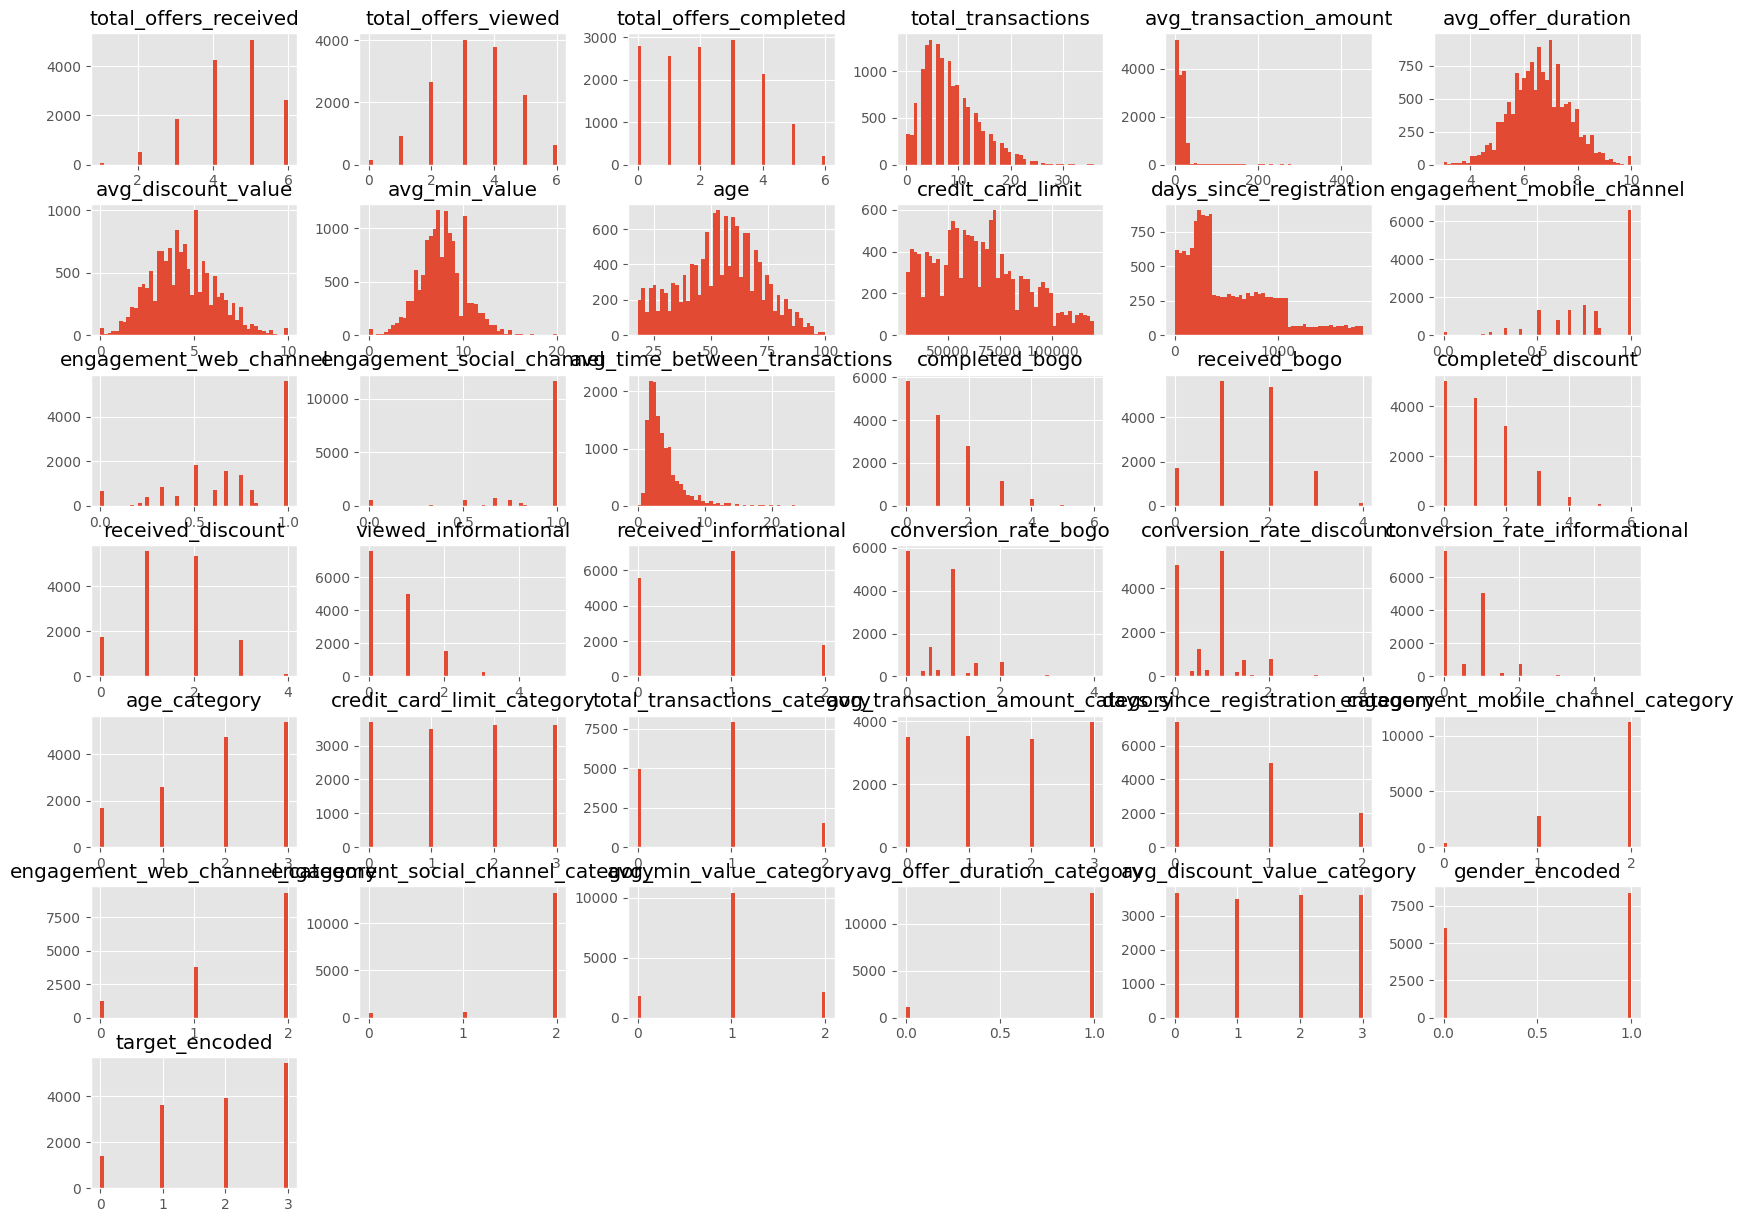

In [0]:
# Histograma das variáveis numéricas
df_individuo.toPandas().hist(bins=50, figsize=(20, 15))
plt.show()

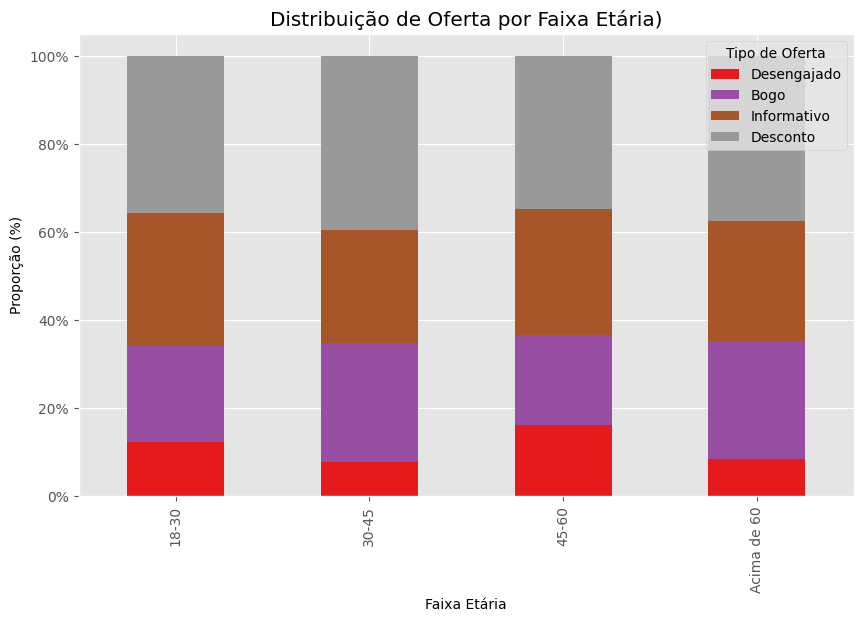

In [0]:
# Calculando as contagens de cada categoria de target_encoded por faixa etária
age_target = df_individuo.groupBy('age_category', 'target_encoded').count()

# Pivotando a tabela para ter as categorias de target_encoded como colunas
age_target_pivot = age_target.groupBy('age_category').pivot('target_encoded').agg(F.sum('count')).fillna(0)

# Normalizando para que cada coluna some 1 (ou 100%)
age_target_prop = age_target_pivot.select(
    'age_category', 
    *[F.col(c) / sum(F.col(c) for c in age_target_pivot.columns[1:]).alias(c) for c in age_target_pivot.columns[1:]]
)

# Coletando os dados para o pandas para plotar com matplotlib
age_target_prop_pd = age_target_prop.toPandas()

# Plotando o gráfico empilhado com eixo Y em 100%
age_target_prop_pd.set_index('age_category').plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set1')

plt.title('Distribuição de Oferta por Faixa Etária)')
plt.xlabel('Faixa Etária')
plt.ylabel('Proporção (%)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['18-30', '30-45', '45-60', 'Acima de 60'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.legend(title='Tipo de Oferta', labels=['Desengajado', 'Bogo', 'Informativo', 'Desconto'])
plt.show()



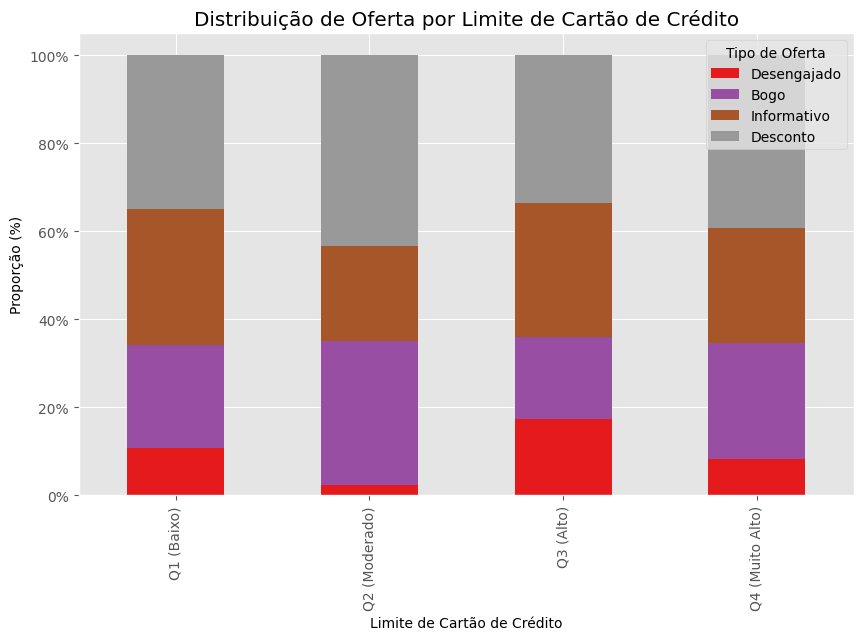

In [0]:
# Calculando as contagens de cada categoria de target_encoded por limite de cartão de crédito
limit_target = df_individuo.groupBy('credit_card_limit_category', 'target_encoded').count()

# Pivotando a tabela para ter as categorias de target_encoded como colunas
limit_target_pivot = limit_target.groupBy('credit_card_limit_category').pivot('target_encoded').agg(F.sum('count')).fillna(0)

# Normalizando para que cada linha (categoria de limite) some 1 (proporção linha a linha)
cols = limit_target_pivot.columns[1:]  # Ignora 'credit_card_limit_category'

# Adiciona coluna com a soma por linha
limit_target_prop = limit_target_pivot.withColumn('row_sum', sum(F.col(c) for c in cols))

# Divide cada coluna pela soma da linha
for c in cols:
    limit_target_prop = limit_target_prop.withColumn(c, F.col(c) / F.col('row_sum'))

# Remove a coluna auxiliar
limit_target_prop = limit_target_prop.drop('row_sum')

# Coletando os dados para o pandas para plotar com matplotlib
limit_target_prop_pd = limit_target_prop.toPandas()

# Plotando o gráfico empilhado com eixo Y em 100% — usando o mesmo colormap 'Set1'
limit_target_prop_pd.set_index('credit_card_limit_category').plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set1')

plt.title('Distribuição de Oferta por Limite de Cartão de Crédito')
plt.xlabel('Limite de Cartão de Crédito')
plt.ylabel('Proporção (%)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Q1 (Baixo)', 'Q2 (Moderado)', 'Q3 (Alto)', 'Q4 (Muito Alto)'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

plt.legend(title='Tipo de Oferta', labels=['Desengajado', 'Bogo', 'Informativo', 'Desconto'])  # Puxa os labels direto
plt.show()



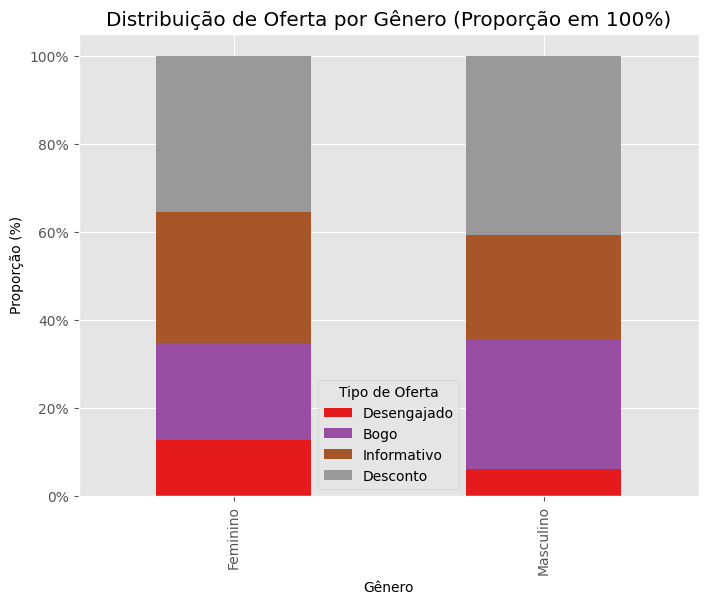

In [0]:
# Calculando as contagens de cada categoria de target_encoded por gênero
gender_target = df_individuo.groupBy('gender_encoded', 'target_encoded').count()

# Pivotando a tabela para ter as categorias de target_encoded como colunas
gender_target_pivot = gender_target.groupBy('gender_encoded').pivot('target_encoded').agg(F.sum('count')).fillna(0)

# Normalizando para que cada linha (categoria de gênero) some 1 (proporção linha a linha)
cols = gender_target_pivot.columns[1:]  # Ignora 'gender_encoded'

# Adiciona coluna com a soma por linha
gender_target_prop = gender_target_pivot.withColumn('row_sum', sum(F.col(c) for c in cols))

# Divide cada coluna pela soma da linha
for c in cols:
    gender_target_prop = gender_target_prop.withColumn(c, F.col(c) / F.col('row_sum'))

# Remove a coluna auxiliar
gender_target_prop = gender_target_prop.drop('row_sum')

# Coletando os dados para o pandas para plotar com matplotlib
gender_target_prop_pd = gender_target_prop.toPandas()

# Se quiser garantir a mesma ordem das colunas (target_encoded)
col_order = ['0', '1', '2', '3']  # ajuste conforme os códigos correspondentes a Desengajado, Bogo, Informativo, Desconto
gender_target_prop_pd = gender_target_prop_pd[['gender_encoded'] + col_order]

# Plotando o gráfico empilhado com eixo Y em 100% — usando o mesmo colormap 'Set1'
gender_target_prop_pd.set_index('gender_encoded').plot(kind='bar', stacked=True, figsize=(8, 6), colormap='Set1')

plt.title('Distribuição de Oferta por Gênero (Proporção em 100%)')
plt.xlabel('Gênero')
plt.ylabel('Proporção (%)')
plt.xticks(ticks=[0, 1], labels=['Feminino', 'Masculino'])  # Ajuste conforme codificação (exemplo)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.legend(title='Tipo de Oferta', labels=['Desengajado', 'Bogo', 'Informativo', 'Desconto'])
plt.show()


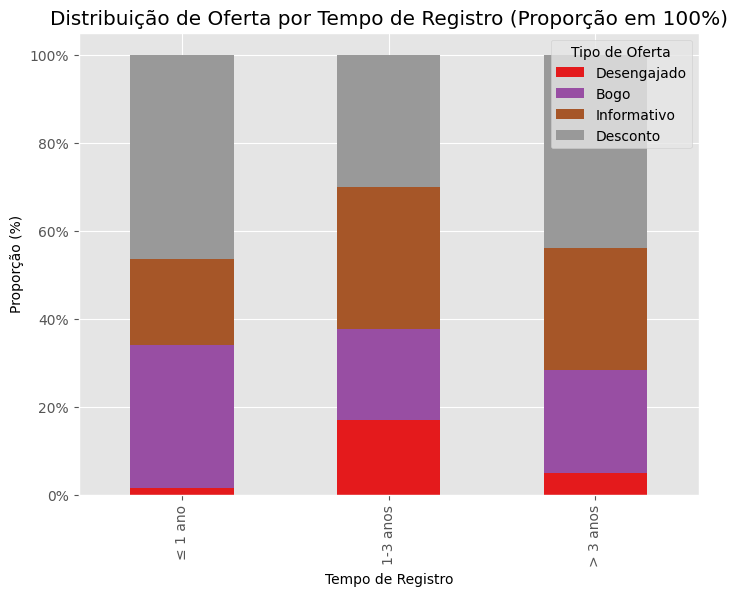

In [0]:
# Calculando as contagens de cada categoria de target_encoded por days_since_registration_category
reg_target = df_individuo.groupBy('days_since_registration_category', 'target_encoded').count()

# Pivotando a tabela para ter as categorias de target_encoded como colunas
reg_target_pivot = reg_target.groupBy('days_since_registration_category').pivot('target_encoded').agg(F.sum('count')).fillna(0)

# Normalizando para que cada linha (categoria de registro) some 1 (proporção linha a linha)
cols = reg_target_pivot.columns[1:]  # Ignora 'days_since_registration_category'

# Adiciona coluna com a soma por linha
reg_target_prop = reg_target_pivot.withColumn('row_sum', sum(F.col(c) for c in cols))

# Divide cada coluna pela soma da linha
for c in cols:
    reg_target_prop = reg_target_prop.withColumn(c, F.col(c) / F.col('row_sum'))

# Remove a coluna auxiliar
reg_target_prop = reg_target_prop.drop('row_sum')

# Coletando os dados para o pandas para plotar com matplotlib
reg_target_prop_pd = reg_target_prop.toPandas()

# Se quiser garantir a mesma ordem das colunas (target_encoded)
col_order = ['0', '1', '2', '3']  # ajuste conforme os códigos correspondentes a Desengajado, Bogo, Informativo, Desconto
reg_target_prop_pd = reg_target_prop_pd[['days_since_registration_category'] + col_order]

# Plotando o gráfico empilhado com eixo Y em 100% — usando o mesmo colormap 'Set1'
reg_target_prop_pd.set_index('days_since_registration_category').plot(kind='bar', stacked=True, figsize=(8, 6), colormap='Set1')

plt.title('Distribuição de Oferta por Tempo de Registro (Proporção em 100%)')
plt.xlabel('Tempo de Registro')
plt.ylabel('Proporção (%)')

plt.xticks(ticks=[0, 1, 2], labels=['≤ 1 ano', '1-3 anos', '> 3 anos'])  # Ajuste conforme suas categorias

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.legend(title='Tipo de Oferta', labels=['Desengajado', 'Bogo', 'Informativo', 'Desconto'])
plt.show()



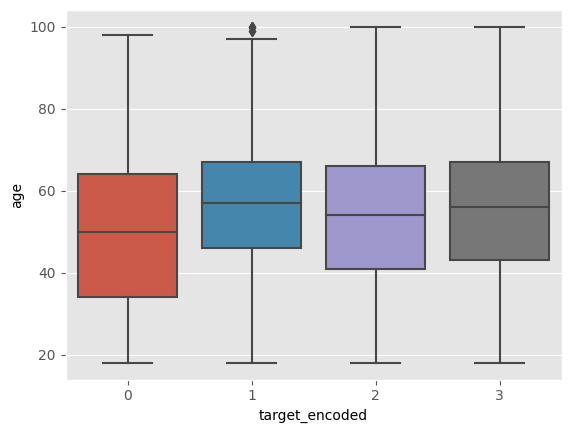

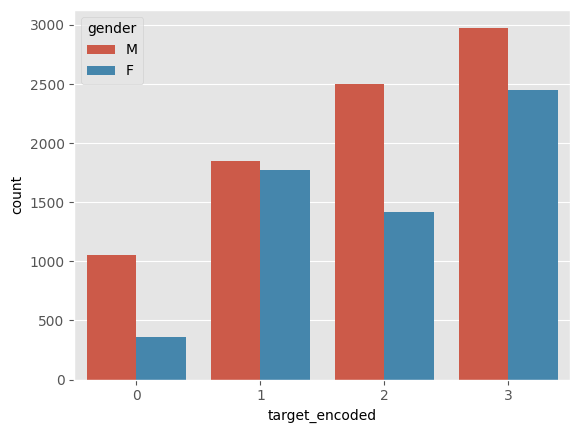

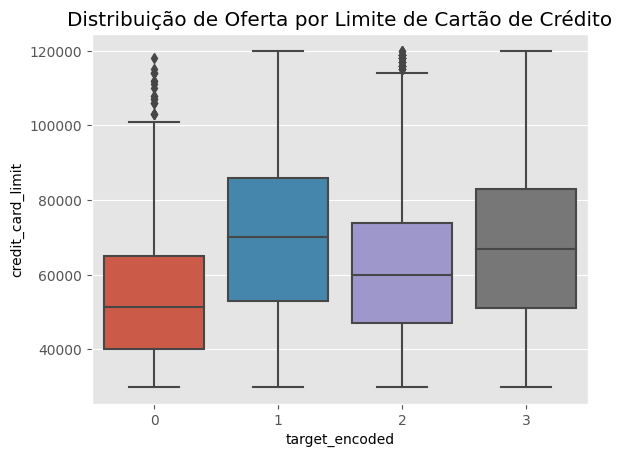

In [0]:
# Convertendo o DataFrame do PySpark para Pandas
df_individuo_pandas = df_individuo.toPandas()

# Agora, você pode usar o Seaborn
sns.boxplot(data=df_individuo_pandas, x='target_encoded', y='age')
plt.show()

# Segmentação por gênero e tipo de oferta
sns.countplot(data=df_individuo_pandas, x='target_encoded', hue='gender')
plt.show()

# Boxplot para ver a distribuição de valores (exemplo: limite do cartão e transação)
sns.boxplot(data=df_individuo.toPandas(), x='target_encoded', y='credit_card_limit')
plt.title('Distribuição de Oferta por Limite de Cartão de Crédito')
plt.show()


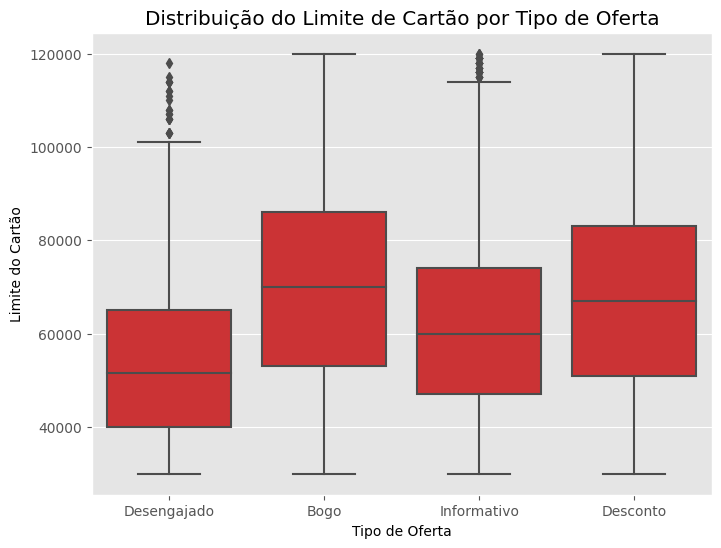

In [0]:
# Paleta de cores Set1 (as mesmas do matplotlib colormap 'Set1')
cores_set1 = sns.color_palette('Set1', n_colors=1)

# Mapear o target_encoded para o label (ajuste conforme seu encoding!)
target_labels = {
    0: 'Desengajado',
    1: 'Bogo',
    2: 'Informativo',
    3: 'Desconto'
}

plt.figure(figsize=(8,6))
sns.boxplot(data=df_individuo_pandas, x='target_encoded', y='credit_card_limit', palette=cores_set1)

plt.title('Distribuição do Limite de Cartão por Tipo de Oferta')
plt.xlabel('Tipo de Oferta')
plt.ylabel('Limite do Cartão')

plt.xticks(ticks=[0,1,2,3], labels=['Desengajado', 'Bogo', 'Informativo', 'Desconto'])
plt.show()



##MODELO

In [0]:
# Preparar para o modelo
columns_to_model = [    
    'gender_encoded',
    'target_encoded',
    'age_category',
    'credit_card_limit_category',
    'total_transactions_category',
    'days_since_registration_category',
    'engagement_mobile_channel_category',
    'engagement_web_channel_category',
    'engagement_social_channel_category',
    'avg_min_value_category',
    'avg_offer_duration_category',
    'avg_discount_value_category'
]

df_model = df_individuo[columns_to_model]


# 1. Lista de variáveis categóricas
categorical_columns = [
       'gender_encoded',
       'age_category',
       'credit_card_limit_category',
       'total_transactions_category',
       'days_since_registration_category',
       'engagement_mobile_channel_category',
       'engagement_web_channel_category',
       'engagement_social_channel_category',
       'avg_min_value_category',
       'avg_offer_duration_category',
       'avg_discount_value_category'
   ]

X = df_model.select(feature_cols)
y = df_model.select('target_encoded')

# 2. Converter para Pandas
X_pandas = X.toPandas()  # Converte features para Pandas
y_pandas = y.toPandas()['target_encoded']  # Ajustar target (coluna)

# Checar e tratar valores ausentes (NaN)
X_pandas = X_pandas.dropna()  # Remove valores ausentes
y_pandas = y_pandas[X_pandas.index]  # Alinha índices de y com X

# Realizar o One-Hot Encoding (Criação de Dummies)
X_pandas = pd.get_dummies(X_pandas, columns=categorical_columns, drop_first=True)

# 3. Divisão entre Treinamento e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X_pandas,
    y_pandas,
    test_size=0.3,
    random_state=42,
    stratify=y_pandas  # Preservar distribuição das classes
)

# 4. Configurar e ajustar o modelo multinomial
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
lr.fit(X_train, y_train)  # Ajustar o modelo nos dados de treino

# 5. Fazer as previsões
y_pred = lr.predict(X_test)

# 6. Avaliar o desempenho do modelo
# Acurácia
acc = accuracy_score(y_test, y_pred)
# F1-Score ponderado
f1 = f1_score(y_test, y_pred, average='weighted')
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

# 7. Imprimir os resultados
print(f'Acurácia: {acc:.4f}')
print(f'F1-Score: {f1:.4f}')
print('Matriz de confusão:')
print(cm)


Acurácia: 0.6133
F1-Score: 0.6077
Matriz de confusão:
[[ 182   84   79   80]
 [  47  551  111  379]
 [  36   95  680  366]
 [  43  186  164 1236]]


In [0]:
# 1. Adicionar a constante (intercepto) aos dados
X_pandas = sm.add_constant(X_pandas)

# 2. Ajustar o modelo multinomial usando MNLogit
model = sm.MNLogit(y_pandas, X_pandas)
result = model.fit(method='newton')  # Método para maximizar a verossimilhança

# 3. Exibir o resumo do modelo
print(result.summary())

# 4. Obter os coeficientes (odds ratio se necessário)
print("\nCoeficientes:")
print(result.params)  # Coeficientes do modelo

# 5. Intervalos de confiança (95% por padrão)
print("\nIntervalos de Confiança dos Coeficientes:")
print(result.conf_int())

# 6. p-Valores
print("\nP-Valores dos Coeficientes:")
print(result.pvalues)


Optimization terminated successfully.
         Current function value: 0.892778
         Iterations 8
                          MNLogit Regression Results                          
Dep. Variable:         target_encoded   No. Observations:                14396
Model:                        MNLogit   Df Residuals:                    14324
Method:                           MLE   Df Model:                           69
Date:                Thu, 01 May 2025   Pseudo R-squ.:                  0.3119
Time:                        23:33:41   Log-Likelihood:                -12852.
converged:                       True   LL-Null:                       -18679.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    target_encoded=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -2.7792      0.3

In [0]:
# 4. Obter os coeficientes (odds ratio se necessário)
print("\nCoeficientes (log-odds):")
print(result.params)  # Coeficientes do modelo

# Coeficientes exponenciados (odds ratios)
print("\nOdds Ratios (exp(coeficientes)):")
print(np.exp(result.params))

# 5. Intervalos de confiança (95% por padrão)
conf = result.conf_int()
print("\nIntervalos de Confiança dos Coeficientes (log-odds):")
print(conf)

# Intervalos de confiança exponenciados (odds ratios)
print("\nIntervalos de Confiança dos Odds Ratios:")
print(np.exp(conf))

# 6. p-Valores
print("\nP-Valores dos Coeficientes:")
print(result.pvalues)

In [0]:
# Verificar se há colunas constantes (sem variação)
print(X_pandas.var())

const                                   0.000000
gender_encoded_1.0                      0.243230
age_category_1                          0.146707
age_category_2                          0.221429
age_category_3                          0.234226
credit_card_limit_category_1            0.183777
credit_card_limit_category_2            0.187791
credit_card_limit_category_3            0.187478
total_transactions_category_1           0.247382
total_transactions_category_2           0.094388
days_since_registration_category_1      0.226789
days_since_registration_category_2      0.119032
engagement_mobile_channel_category_1    0.155445
engagement_mobile_channel_category_2    0.171918
engagement_web_channel_category_1       0.194692
engagement_web_channel_category_2       0.227628
engagement_social_channel_category_1    0.041089
engagement_social_channel_category_2    0.073857
avg_min_value_category_1                0.199236
avg_min_value_category_2                0.126026
avg_offer_duration_c

In [0]:
# Prever as probabilidades para o conjunto de teste
y_probabilities = lr.predict_proba(X_test)

# Transformar em um DataFrame para facilitar a visualização
probabilities_df = pd.DataFrame(
    y_probabilities,
    columns=[f"Probabilidade_target_{i}" for i in range(y_probabilities.shape[1])],
    index=X_test.index  # Manter o mesmo índice dos dados de teste
)

# Exibir as probabilidades
probabilities_df.display()

Probabilidade_target_0,Probabilidade_target_1,Probabilidade_target_2,Probabilidade_target_3
0.006217566051186345,0.4175075281237214,0.1110133560425761,0.4652615497825162
0.08353113504844364,0.7148936357706895,0.09518321149823834,0.1063920176826284
0.38284939235767906,0.344193912939355,0.18555585891631476,0.08740083578665107
0.026824162386665473,0.8032952581475301,0.01351118995603332,0.15636938950977103
0.01993152826107665,0.279184584403488,0.31786389423492833,0.38301999310050705
7.105948763502315E-4,0.2909885469093721,0.10855102098430444,0.5997498372299732
0.1803055041312385,0.07787759949195208,0.560017965761947,0.18179893061486257
4.7481310067761174E-4,0.011352431555591704,0.01878929455694552,0.9693834607867852
0.011877376088974767,0.6855276976249836,0.07348094144829903,0.22911398483774265
0.01847869018444581,0.0024097659135107466,0.978048843031418,0.00106270087062539


In [0]:
corr_matrix = X_pandas.corr()
display(corr_matrix)

gender_encoded,age_category,credit_card_limit_category,total_transactions_category,days_since_registration_category,engagement_mobile_channel_category,engagement_web_channel_category,engagement_social_channel_category,avg_min_value_category,avg_offer_duration_category,avg_discount_value_category
1.0,-0.14317396818076164,-0.21988812938912927,0.03201305772858807,-0.0023270104900813466,-0.015045389015183047,-0.049937083142931334,0.01685222280013593,-0.030675774962269794,-0.031047791096060196,-0.01883233335796851
-0.14317396818076164,1.0,0.3069621734640324,-0.1428423694041122,0.023183808192464215,0.020116935529193275,0.07013984335350802,-0.03308130666900223,0.02853567025571761,0.015562815145156188,-7.963809255924094E-4
-0.21988812938912927,0.3069621734640324,1.0,-0.21378664153749832,0.0561800815357869,0.04366916987034901,0.14348026060502234,-0.05251631241044221,0.05554996513622411,0.017152066107968583,0.020530568126603133
0.03201305772858807,-0.1428423694041122,-0.21378664153749832,1.0,0.41628463308054436,0.14776743640573164,0.11432749444960534,0.12650352433784326,0.06482440059310456,0.08591582585324915,0.041270931175009996
-0.0023270104900813466,0.023183808192464215,0.0561800815357869,0.41628463308054436,1.0,0.0485437107227074,0.04324551444965934,-0.01190068129782488,0.03447673355679141,0.01561896866384744,0.011680919892982231
-0.015045389015183047,0.020116935529193275,0.04366916987034901,0.14776743640573164,0.0485437107227074,1.0,0.6702123218653255,0.41946060677686703,0.02856853916053024,-0.013026088763260954,0.08130338358927541
-0.049937083142931334,0.07013984335350802,0.14348026060502234,0.11432749444960534,0.04324551444965934,0.6702123218653255,1.0,0.21505480837763571,-0.017025410065065888,0.02520798417631905,0.029571430081737918
0.01685222280013593,-0.03308130666900223,-0.05251631241044221,0.12650352433784326,-0.01190068129782488,0.41946060677686703,0.21505480837763571,1.0,-0.026091047850585015,-0.006361042309916468,0.11079926082763612
-0.030675774962269794,0.02853567025571761,0.05554996513622411,0.06482440059310456,0.03447673355679141,0.02856853916053024,-0.017025410065065888,-0.026091047850585015,1.0,0.43265314649769665,0.29464774055713905
-0.031047791096060196,0.015562815145156188,0.017152066107968583,0.08591582585324915,0.01561896866384744,-0.013026088763260954,0.02520798417631905,-0.006361042309916468,0.43265314649769665,1.0,0.12172421036546721
